# Regression & Multilinear Models in Quantitative Finance

> **Welcome!** This notebook walks you through the most important regression techniques used by professional quants — from the single most-used equation in finance (CAPM beta) to machine-learning regularization methods (Ridge/Lasso) and dimension reduction (PCA). **No prior knowledge of regression is assumed.** Every section starts with a plain-English explanation before introducing any mathematics.

## What You Will Learn

| # | Technique | What It Answers | Time to Master |
|---|-----------|----------------|---------------|
| 1 | **Imports & Mock Data** | Setting up a realistic multi-factor dataset | Foundation |
| 2 | **Simple OLS / CAPM** | "What is this stock's market beta?" | 15 min |
| 3 | **Multiple Regression (Fama-French)** | "Which risk factors drive this stock?" | 20 min |
| 4 | **Gauss-Markov Diagnostics** | "Can I trust my regression output?" | 20 min |
| 5 | **Multicollinearity (VIF)** | "Are my factors redundant?" | 15 min |
| 6 | **Heteroskedasticity** | "Is the noise level changing over time?" | 15 min |
| 7 | **Fama-MacBeth** | "Is this factor rewarded across many stocks?" | 20 min |
| 8 | **Ridge Regression** | "How do I stabilise noisy factor loadings?" | 20 min |
| 9 | **Lasso Regression** | "Which factors actually matter?" | 20 min |
| 10 | **Rolling Regression** | "Has the relationship changed over time?" | 20 min |
| 11 | **Principal Component Regression** | "How do I handle 100 correlated variables?" | 25 min |
| 12 | **Summary & Cheat Sheet** | Decision flowchart + formula reference | — |

## The Big Picture

```
Every regression in finance answers one of three questions:

  ① "What drives this asset's returns?"   → OLS, Multiple Regression, Fama-French
  ② "Which variables actually matter?"    → Lasso, Ridge, PCR
  ③ "Has the relationship changed?"       → Rolling Regression, Chow Test
```

**Data used in this notebook:** 500 trading days of synthetic stock returns generated from a known 4-factor model (market, SMB, HML, momentum). Since we know the true parameters, we can verify that our methods recover them correctly.

## 1. Import Libraries & Generate Mock Financial Data

### What We Import and Why

| Library | Purpose in This Notebook |
|---------|--------------------------|
| `numpy`, `pandas` | Array math and tabular data handling |
| `matplotlib`, `seaborn` | All visualizations |
| `statsmodels` | OLS regression, diagnostics, Gauss-Markov tests, VIF |
| `sklearn` | Ridge, Lasso, cross-validation, PCA |
| `scipy.stats` | Q-Q plots and normality tests |

### Mock Dataset Design

We generate 500 days of synthetic stock returns using a **known 4-factor model**. This is ideal for beginners because:
- We know the *true* alpha and betas beforehand
- We can verify that our regression methods recover them correctly
- We control the noise level and factor structure

> **The ground truth (true parameters):**
> - True α (daily) = 0.0002 (+5% annualised)
> - True β_MKT = 1.20, β_SMB = 0.40, β_HML = 0.25, β_MOM = -0.15

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import Ridge, Lasso, LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
np.random.seed(42)

# ── Dataset 1: Time-series (500 trading days) ─────────────────────────────────
# Used for: CAPM, Fama-French, OLS diagnostics, rolling regression
n = 500
dates = pd.date_range(start='2022-01-01', periods=n, freq='B')

# True factor exposures (the "ground truth" we're trying to recover)
TRUE_BETA_MKT   = 1.20   # market beta
TRUE_BETA_SMB   = 0.40   # small-cap tilt
TRUE_BETA_HML   = 0.25   # value tilt
TRUE_BETA_MOM   = -0.15  # slight negative momentum
TRUE_ALPHA      = 0.0002  # daily alpha (~5% annualised)

# Simulate daily factor returns (realistic magnitudes)
market_returns = np.random.normal(0.0004, 0.012, n)   # ~10% annual, 12% vol
smb_factor     = np.random.normal(0.0001, 0.006, n)
hml_factor     = np.random.normal(0.0001, 0.005, n)
mom_factor     = np.random.normal(0.0002, 0.007, n)
risk_free      = np.full(n, 0.00008)                  # ~2% annual

# Generate stock returns from the true model + noise
epsilon = np.random.normal(0, 0.008, n)               # idiosyncratic risk
stock_returns = (TRUE_ALPHA
                 + TRUE_BETA_MKT * (market_returns - risk_free)
                 + TRUE_BETA_SMB * smb_factor
                 + TRUE_BETA_HML * hml_factor
                 + TRUE_BETA_MOM * mom_factor
                 + epsilon)

# Macro variables (for macro-regression examples)
gdp_growth  = np.random.normal(0.005, 0.003, n).cumsum()
inflation   = 0.02/252 + np.random.normal(0, 0.001, n).cumsum()
credit_sprd = 0.02 + np.random.normal(0, 0.002, n).cumsum()

# Assemble time-series DataFrame
df_ts = pd.DataFrame({
    'stock_ret':  stock_returns,
    'mkt_excess': market_returns - risk_free,
    'smb':        smb_factor,
    'hml':        hml_factor,
    'mom':        mom_factor,
    'gdp':        gdp_growth,
    'inflation':  inflation,
    'credit_sprd':credit_sprd,
}, index=dates)

# ── Dataset 2: Cross-sectional (100 stocks) ───────────────────────────────────
# Used for: cross-sectional regression, Fama-MacBeth, Ridge, Lasso, PCR
n_stocks = 100

pe_ratio       = np.random.lognormal(np.log(20), 0.5, n_stocks)
pb_ratio       = np.random.lognormal(np.log(3), 0.4, n_stocks)
roe            = np.random.normal(0.12, 0.06, n_stocks)
debt_equity    = np.random.lognormal(np.log(0.8), 0.6, n_stocks)
market_cap_log = np.random.normal(8, 1.5, n_stocks)

# Forward returns driven by fundamentals (true relationship + noise)
fw_returns = (-0.002 * np.log(pe_ratio)      # value: lower P/E → higher return
              + 0.015 * roe                   # profitability
              - 0.005 * debt_equity           # leverage penalised
              + 0.003 * market_cap_log        # slight size effect
              + np.random.normal(0, 0.04, n_stocks))

df_cross = pd.DataFrame({
    'fw_return':   fw_returns,
    'log_pe':      np.log(pe_ratio),
    'log_pb':      np.log(pb_ratio),
    'roe':         roe,
    'debt_equity': debt_equity,
    'log_mktcap':  market_cap_log,
})

cs_features = ['log_pe', 'log_pb', 'roe', 'debt_equity', 'log_mktcap']

print("✓ Time-series dataset:", df_ts.shape, "  (500 trading days × 8 variables)")
print("✓ Cross-sectional dataset:", df_cross.shape, "  (100 stocks × 6 variables)")
print()
print("Time-series dataset (first 5 rows):")
print(df_ts.head())
print()
print("Cross-sectional dataset (first 5 rows):")
print(df_cross.head())

✓ Time-series dataset: (500, 8)   (500 trading days × 8 variables)
✓ Cross-sectional dataset: (100, 6)   (100 stocks × 6 variables)

Time-series dataset (first 5 rows):
            stock_ret  mkt_excess       smb       hml       mom       gdp  \
2022-01-03   0.005525    0.006281  0.005657  0.007097  0.005649  0.006712   
2022-01-04   0.003789   -0.001339  0.011556  0.004723 -0.003658  0.014616   
2022-01-05   0.001183    0.008092 -0.008291  0.000398 -0.005527  0.018622   
2022-01-06   0.020633    0.018596  0.003478 -0.003135  0.000176  0.021786   
2022-01-07  -0.018412   -0.002490 -0.003804  0.003591 -0.000991  0.023530   

            inflation  credit_sprd  
2022-01-03  -0.001828     0.022361  
2022-01-04  -0.002689     0.021107  
2022-01-05  -0.003102     0.021197  
2022-01-06  -0.001215     0.021299  
2022-01-07  -0.000658     0.020296  

Cross-sectional dataset (first 5 rows):
   fw_return    log_pe    log_pb       roe  debt_equity  log_mktcap
0  -0.018369  2.563985  0.498524  0.1

## 2. Simple Linear Regression (OLS) — CAPM Beta Estimation

> **In plain English:** OLS draws the single straight line that best fits a cloud of data points by minimising the total squared error. In finance, the most famous use is fitting a line through a scatter plot of stock returns vs market returns — the slope of that line is the stock's **beta**.
>
> **Analogy:** Imagine weighing a bag of apples. You notice that every time the market goes up 1%, your stock tends to go up 1.2%. That "1.2" is the beta — a simple linear ratio. OLS finds that ratio precisely, even when the data is noisy.
>
> **Two numbers matter most:**
> - **β (slope)** — market sensitivity. β = 1.2 means "my stock amplifies market moves by 20%"
> - **α (intercept)** — return unexplained by the market. A positive, statistically significant α means genuine skill (or genuine luck — you need years of data to tell the difference)

### What Is It?
OLS (Ordinary Least Squares) finds the line $\hat{y} = \alpha + \beta x$ that minimises the sum of squared residuals:
$$\hat{\beta} = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}, \quad \hat{\alpha} = \bar{R}_i - \hat{\beta}\bar{R}_m$$

### Why Quants Need It
- **CAPM Beta Estimation**: The single most-used regression in finance. Every equity risk model starts with $R_i - R_f = \alpha + \beta(R_m - R_f) + \varepsilon$.
- **Alpha Attribution**: A portfolio manager proves that outperformance is genuine alpha, not just hidden market beta inside a "market-neutral" fund.
- **Hedge Ratio Calculation**: A derivatives desk regresses an option's P&L on the underlying to find the delta-hedge ratio via OLS, especially for illiquid instruments without closed-form Greeks.
- **ETF Replication**: ETF providers regress the basket price on the index to compute tracking error and verify replication quality daily.

**Interpreting CAPM Regression:**
| Term | Meaning | Example |
|------|---------|---------|
| α (intercept) | Return unexplained by market — genuine skill (or luck) | α = 0.0002/day → +5% annualised |
| β (slope) | Sensitivity to market; β > 1 amplifies market moves | β = 1.2 → stock moves ±12% when market moves ±10% |
| R² | Fraction of stock return variance explained by the market | R² = 0.7 → 70% of risk is market-driven |
| p-value of α | Test whether alpha is statistically significant | p < 0.05 → alpha is real (not just noise) |

CAPM OLS REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     1363.
Date:                Sun, 31 May 2026   Prob (F-statistic):          1.09e-144
Time:                        00:03:51   Log-Likelihood:                 1686.2
No. Observations:                 500   AIC:                            -3368.
Df Residuals:                     498   BIC:                            -3360.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003   

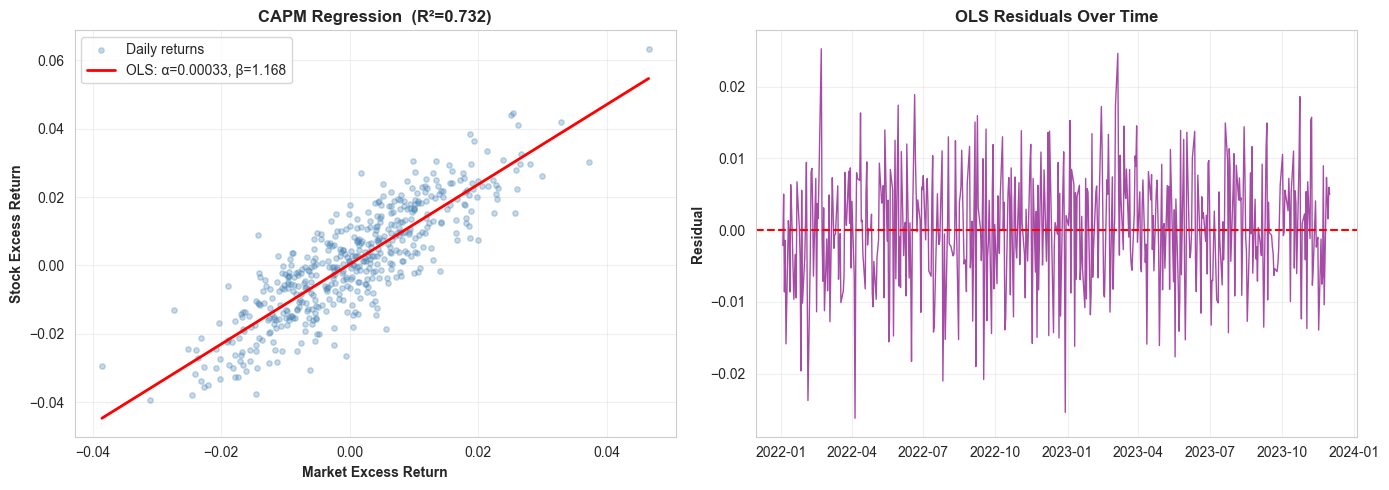


✓ Annualised alpha: 8.39%
✓ Beta (market sensitivity): 1.1677
✓ R²: 0.7325 — market explains 73.2% of return variance


In [3]:
# ── Simple OLS: CAPM Beta Estimation ─────────────────────────────────────────
y = df_ts['stock_ret'].values
X_capm = sm.add_constant(df_ts['mkt_excess'].values)

ols_capm = sm.OLS(y, X_capm).fit()
alpha_hat = ols_capm.params[0]
beta_hat  = ols_capm.params[1]
r2        = ols_capm.rsquared

print("=" * 65)
print("CAPM OLS REGRESSION RESULTS")
print("=" * 65)
print(ols_capm.summary())

print(f"\nTrue  α = {TRUE_ALPHA:.6f}  |  Estimated α = {alpha_hat:.6f}")
print(f"True  β = {TRUE_BETA_MKT:.4f}      |  Estimated β = {beta_hat:.4f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter + regression line
ax = axes[0]
mkt_ex = df_ts['mkt_excess'].values
ax.scatter(mkt_ex, y, alpha=0.3, s=15, color='steelblue', label='Daily returns')
x_line = np.linspace(mkt_ex.min(), mkt_ex.max(), 200)
ax.plot(x_line, alpha_hat + beta_hat * x_line, color='red', linewidth=2,
        label=f'OLS: α={alpha_hat:.5f}, β={beta_hat:.3f}')
ax.set_xlabel('Market Excess Return', fontweight='bold')
ax.set_ylabel('Stock Excess Return', fontweight='bold')
ax.set_title(f'CAPM Regression  (R²={r2:.3f})', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Residuals over time
ax = axes[1]
ax.plot(df_ts.index, ols_capm.resid, linewidth=1, color='purple', alpha=0.7)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('OLS Residuals Over Time', fontweight='bold')
ax.set_ylabel('Residual', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Annualised alpha: {alpha_hat * 252 * 100:.2f}%")
print(f"✓ Beta (market sensitivity): {beta_hat:.4f}")
print(f"✓ R²: {r2:.4f} — market explains {r2*100:.1f}% of return variance")


## 3. Multiple Linear Regression — Fama-French 4-Factor Model

> **In plain English:** Single-factor CAPM only asks "how much does this stock move with the market?" But a stock can also behave like a small-cap stock (SMB factor), or like a cheap/value stock (HML factor), or like a stock that has been winning recently (momentum). Multiple regression measures ALL of these at once, so you can see the true sources of a stock's risk.
>
> **Analogy:** A nutritionist doesn't just measure "total calories" — they break down carbs, protein, fat, and vitamins separately. Multiple regression does the same for a stock's return: it decomposes the total return into contributions from each risk factor simultaneously.
>
> **Why add more factors?**
> | Scenario | What CAPM says | What 4-Factor says |
> |----------|---------------|-------------------|
> | Small-cap tech stock | β = 1.3, α = 0 | β_MKT=1.1, β_SMB=+0.8 (small-cap risk) |
> | Cheap value stock | β = 0.9, α = +0.3% | β_MKT=0.8, β_HML=+0.6 (value risk, not alpha) |
> | Hot momentum stock | β = 1.2, α = +0.5% | β_MKT=1.0, β_MOM=+0.7 (momentum risk, not alpha) |
>
> The "alpha" in CAPM often disappears once you add the missing factors — revealing it was just unaccounted risk.

### What Is It?
Multiple linear regression extends OLS to several predictors simultaneously:
$$R_i - R_f = \alpha + \beta_{\text{MKT}}(R_m - R_f) + \beta_{\text{SMB}}\cdot\text{SMB} + \beta_{\text{HML}}\cdot\text{HML} + \beta_{\text{MOM}}\cdot\text{MOM} + \varepsilon$$

The OLS estimator in matrix form: $\hat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top y$

### Why Quants Need It
- **Risk Decomposition**: A single-factor CAPM beta blends together market risk, size risk, value risk, and momentum. MLR separates them cleanly.
- **Factor Investing (Smart Beta ETFs)**: iShares, Vanguard, and DFA use multi-factor regression to build portfolios that tilt toward factors with known historical risk premia.
- **Performance Attribution (Brinson-Hood-Beebower)**: A pension fund attribution report decomposes total return into factor contributions. Without MLR, you cannot distinguish value skill from market timing from stock selection.
- **Risk Model Calibration (Barra/Axioma)**: Commercial risk models (Barra USE4, Axioma Worldwide) are fundamentally multi-factor regressions across hundreds of factors, used daily at every major investment firm.

### What Each Coefficient Tells You
| Factor | Positive β means... | Practical Impact |
|--------|-------------------|-------------|
| MKT (market) | Stock amplifies market moves | β > 1 = leveraged market exposure |
| SMB (small-minus-big) | Stock behaves like small caps | Adds size premium risk |
| HML (high-minus-low B/P) | Stock behaves like value stocks | Style-box drift signal |
| MOM (momentum) | Stock rides past winners | Drawdown risk in reversals |

FAMA-FRENCH 4-FACTOR MODEL RESULTS
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     424.0
Date:                Sun, 31 May 2026   Prob (F-statistic):          2.42e-158
Time:                        00:24:25   Log-Likelihood:                 1728.5
No. Observations:                 500   AIC:                            -3447.
Df Residuals:                     495   BIC:                            -3426.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.

AttributeError: 'numpy.ndarray' object has no attribute 'values'

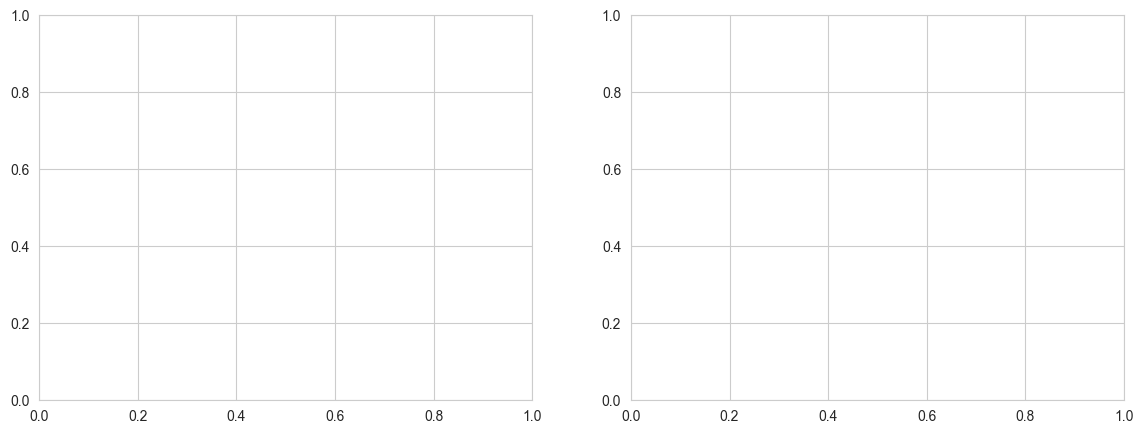

In [ ]:
# ── Fama-French 4-Factor OLS ─────────────────────────────────────────────────
factor_cols = ['mkt_excess', 'smb', 'hml', 'mom']
X_ff4 = sm.add_constant(df_ts[factor_cols].values)
ols_ff4 = sm.OLS(y, X_ff4).fit()

print("=" * 65)
print("FAMA-FRENCH 4-FACTOR MODEL RESULTS")
print("=" * 65)
print(ols_ff4.summary())

# Compare true vs estimated betas
true_betas  = [TRUE_ALPHA, TRUE_BETA_MKT, TRUE_BETA_SMB, TRUE_BETA_HML, TRUE_BETA_MOM]
est_betas   = ols_ff4.params
labels      = ['α', 'β_MKT', 'β_SMB', 'β_HML', 'β_MOM']

print("\n" + "=" * 50)
print(f"{'Factor':<10} {'True':>10} {'Estimated':>12} {'t-stat':>10} {'p-value':>10}")
print("-" * 50)
for lab, tr, est, tstat, pv in zip(labels, true_betas, est_betas,
                                    ols_ff4.tvalues, ols_ff4.pvalues):
    sig = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else ''
    print(f"{lab:<10} {tr:>10.5f} {est:>12.5f} {tstat:>10.3f} {pv:>10.4f} {sig}")

print(f"\nCAPM R² = {ols_capm.rsquared:.4f}  vs  4-Factor R² = {ols_ff4.rsquared:.4f}")
print(f"Improvement from adding SMB/HML/MOM: +{(ols_ff4.rsquared - ols_capm.rsquared)*100:.2f}%")

# ── Coefficient plot with confidence intervals ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ci = np.asarray(ols_ff4.conf_int())  # ensure numpy (5, 2)
coef_vals  = ols_ff4.params[1:]       # already numpy array
lower_vals = ci[1:, 0]
upper_vals = ci[1:, 1]
coef_df = pd.DataFrame({
    'coef':  coef_vals,
    'lower': lower_vals,
    'upper': upper_vals,
    'true':  true_betas[1:]
}, index=factor_cols)

y_pos = np.arange(len(coef_df))
xerr = np.array([coef_vals - lower_vals, upper_vals - coef_vals])
ax.barh(y_pos, coef_df['coef'], xerr=xerr,
        color='steelblue', alpha=0.7, capsize=5, label='Estimated β (95% CI)')
ax.scatter(coef_df['true'], y_pos, color='red', zorder=5, s=80, label='True β')
ax.set_yticks(y_pos)
ax.set_yticklabels(factor_cols, fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Factor Loadings with 95% Confidence Intervals', fontweight='bold')
ax.set_xlabel('Coefficient', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='x')

# Actual vs Fitted
ax = axes[1]
fitted = ols_ff4.fittedvalues
ax.scatter(fitted, y, alpha=0.3, s=15, color='steelblue')
lim = max(abs(fitted).max(), abs(y).max())
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=2, label='Perfect fit')
ax.set_xlabel('Fitted Values', fontweight='bold')
ax.set_ylabel('Actual Returns', fontweight='bold')
ax.set_title('Actual vs Fitted Returns', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4. OLS Assumptions & Gauss-Markov Theorem

> **In plain English:** OLS produces the best possible estimates — but *only if* five conditions hold. Think of these like the conditions on a loan: you can borrow money (get valid estimates), but only if you meet the requirements. Violating them doesn't stop the regression from running; it just makes the results quietly wrong.
>
> **The test you should always run before trusting a regression:**
> 1. **Plot residuals vs fitted values** — should look like a random cloud with no pattern
> 2. **Q-Q plot of residuals** — points should fall on the diagonal line
> 3. **Durbin-Watson test** — value near 2.0 = no autocorrelation (good)
> 4. **Breusch-Pagan test** — p > 0.05 = constant variance (good)
>
> **What goes wrong when assumptions fail:**
> - Residuals have a curved pattern → your model is missing a non-linear relationship
> - Residuals fan out over time → use **robust standard errors (HC3)** or **GARCH**
> - Residuals cluster in groups → you have omitted a regime variable
> - Residuals look like a sine wave → you have omitted seasonality

### What Is It?
OLS is **BLUE** (Best Linear Unbiased Estimator) *only if* the Gauss-Markov assumptions hold:

| Assumption | Requirement | What Violates It in Finance |
|-----------|------------|-------------|
| GM1 | Linearity in parameters | Omitted nonlinear relationships |
| GM2 | Random sampling / exogeneity | Endogenous regressors (e.g., price → factor AND factor → price) |
| GM3 | No perfect multicollinearity | Highly correlated features (e.g., P/E and P/B together) |
| GM4 | Zero conditional mean: $E(\varepsilon\|X)=0$ | Omitted variables, model misspecification |
| GM5 | Homoskedasticity: $\text{Var}(\varepsilon\|X)=\sigma^2$ | Volatility clustering (ARCH effects) |
| GM6 | No autocorrelation: $\text{Cov}(\varepsilon_i,\varepsilon_j)=0$ | Any time-series return data |

### Why Quants Need to Check These
- **Biased Betas**: If GM4 fails (you omit the HML factor but the stock has a value tilt), the CAPM beta is biased — you attribute to alpha what is really compensation for value risk.
- **Wrong Significance Tests**: Heteroskedasticity (GM5) and autocorrelation (GM6) produce artificially small standard errors. A factor appears statistically significant when it isn't — leading to false alpha discovery.
- **Unstable Predictions**: Near-multicollinearity (GM3) makes coefficient estimates numerically unstable — changing 1 data point can flip a coefficient sign. Dangerous when building factor models or running quantitative screens.

> **How to read the diagnostic plots:**
> - **Residuals vs Fitted** — random cloud around zero = good; any curve/funnel = problem
> - **Q-Q Plot** — points hugging the diagonal = residuals are normally distributed
> - **Scale-Location** — flat red line = constant variance (homoskedasticity)
> - **Residuals over time** — no pattern = no autocorrelation

In [ ]:
# ── Residual Diagnostic Plots (4-factor model) ───────────────────────────────
resid = ols_ff4.resid
fitted = ols_ff4.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(fitted, resid, alpha=0.4, s=15, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted Values', fontweight='bold')
ax.set_ylabel('Residuals', fontweight='bold')
ax.set_title('Residuals vs Fitted\n(check: random cloud around 0 = good)', fontweight='bold')
ax.grid(alpha=0.3)

# 2. Q-Q plot of residuals
ax = axes[0, 1]
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q Plot of Residuals\n(check: points on diagonal = normality holds)', fontweight='bold')
ax.grid(alpha=0.3)

# 3. Scale-Location (sqrt|residuals| vs fitted)
ax = axes[1, 0]
ax.scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.4, s=15, color='green')
z = np.polyfit(fitted, np.sqrt(np.abs(resid)), 1)
x_line = np.linspace(fitted.min(), fitted.max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2)
ax.set_xlabel('Fitted Values', fontweight='bold')
ax.set_ylabel('√|Residuals|', fontweight='bold')
ax.set_title('Scale-Location Plot\n(check: flat red line = homoskedasticity)', fontweight='bold')
ax.grid(alpha=0.3)

# 4. Residuals over time (autocorrelation check)
ax = axes[1, 1]
ax.plot(df_ts.index, resid, linewidth=1, color='purple', alpha=0.7)
ax.axhline(0, color='red', linestyle='--')
ax.fill_between(df_ts.index, resid, 0, alpha=0.2, color='purple')
ax.set_title('Residuals Over Time\n(check: no patterns = no autocorrelation)', fontweight='bold')
ax.set_ylabel('Residual', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Formal tests
dw = durbin_watson(resid)
_, bp_pvalue, _, _ = het_breuschpagan(resid, X_ff4)
sw_stat, sw_pvalue = stats.shapiro(resid[:50])

print("=" * 55)
print("REGRESSION ASSUMPTION TESTS")
print("=" * 55)
print(f"Durbin-Watson (autocorrelation) : {dw:.4f}  {'✓ OK (near 2)' if 1.5 < dw < 2.5 else '⚠ Potential autocorrelation'}")
print(f"Breusch-Pagan p-value (hetero)  : {bp_pvalue:.4f}  {'✓ Homoskedastic' if bp_pvalue > 0.05 else '⚠ Heteroskedasticity detected'}")
print(f"Shapiro-Wilk p-value (normality): {sw_pvalue:.4f}  {'✓ Normal residuals' if sw_pvalue > 0.05 else '⚠ Non-normal residuals'}")


## 5. Multicollinearity — Variance Inflation Factor (VIF)

> **In plain English:** When two predictors are almost identical (e.g., P/E ratio and EV/EBITDA both measure "cheapness"), the regression can't figure out which one is doing the work. The result: both get wildly unreliable coefficients that might flip sign from one month to the next, even though the combined prediction is fine.
>
> **Analogy:** Imagine two detectives who always arrive at crime scenes together and always agree on the suspect. If you ask "which detective identified the suspect?", you can't tell — you only know *together* they got it right. VIF measures how much each predictor overlaps with the others.
>
> **The VIF traffic light:**
> | VIF Value | Meaning | Action |
> |-----------|---------|--------|
> | VIF < 5 | Low correlation | 🟢 No problem |
> | 5 ≤ VIF < 10 | Moderate correlation | 🟡 Monitor; consider merging factors |
> | VIF ≥ 10 | Severe collinearity | 🔴 Drop/combine factors or use Ridge/PCR |

### What Is It?
Multicollinearity occurs when predictors are highly correlated. The **Variance Inflation Factor** quantifies how much a predictor's variance is inflated by correlation with others:
$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$
where $R^2_j$ is obtained by regressing $X_j$ on all other predictors.

**Rule of thumb**: VIF > 5 is concerning; VIF > 10 is severe.

### Why Quants Need It
- **Unstable Factor Betas**: In a risk model with correlated factors (P/E, P/B, and EV/EBITDA all included), VIF > 10 means tiny sample changes produce enormous coefficient swings. Barra and Axioma orthogonalise factors precisely to solve this.
- **Misleading Attribution**: A multi-factor attribution report may show a huge positive beta on one value factor and a large negative beta on a correlated sub-factor — both artefacts of collinearity. The combined net effect is correct, but individual explanations are wrong.
- **Signal Redundancy in Quant Screens**: A model with 50 highly correlated leverage ratios cannot reliably rank stocks. Detecting VIF > 10 drives factor consolidation or PCA (covered later).

> **Key insight:** High VIF doesn't bias predictions — it only makes *individual coefficient interpretation* unreliable. If your goal is pure prediction (not attribution), high VIF is less dangerous. But for factor risk models or performance attribution, it's critical to fix.

In [ ]:
# ── VIF on 4-factor model ─────────────────────────────────────────────────────
X_ff4_df = sm.add_constant(df_ts[factor_cols])

vif_data = pd.DataFrame({
    'Feature': factor_cols,
    'VIF': [variance_inflation_factor(X_ff4_df.values, i+1) for i in range(len(factor_cols))]
})
print("=" * 40)
print("VARIANCE INFLATION FACTORS")
print("=" * 40)
print(vif_data.to_string(index=False))

# ── Now demonstrate with correlated factors ───────────────────────────────────
print("\n── Demonstrating high-VIF scenario ──")
# Add a nearly-redundant factor (smb ≈ 0.9*smb + noise)
df_ts['smb_corr'] = 0.90 * df_ts['smb'] + np.random.normal(0, 0.001, n)

factor_cols_bad = ['mkt_excess', 'smb', 'hml', 'mom', 'smb_corr']
X_bad = sm.add_constant(df_ts[factor_cols_bad])
vif_bad = pd.DataFrame({
    'Feature': factor_cols_bad,
    'VIF': [variance_inflation_factor(X_bad.values, i+1) for i in range(len(factor_cols_bad))]
})
print(vif_bad.to_string(index=False))
print("\n⚠ High VIF on smb / smb_corr — these factors are nearly collinear")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap (good model)
ax = axes[0]
corr = df_ts[factor_cols].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Factor Correlation Matrix\n(Good Model — Low VIF)', fontweight='bold')

# VIF bar chart
ax = axes[1]
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in vif_bad['VIF']]
ax.barh(vif_bad['Feature'], vif_bad['VIF'], color=colors, alpha=0.8)
ax.axvline(5, color='orange', linestyle='--', linewidth=2, label='VIF=5 (warning)')
ax.axvline(10, color='red', linestyle='--', linewidth=2, label='VIF=10 (severe)')
ax.set_xlabel('VIF', fontweight='bold')
ax.set_title('VIF — High Collinearity Example\n(smb ≈ smb_corr)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## 6. Heteroskedasticity — Breusch-Pagan & White Tests

> **In plain English:** OLS assumes that the "noise" in the model has the same spread everywhere. **Heteroskedasticity** means the noise is small in calm periods and large in turbulent periods — exactly what happens in financial returns due to volatility clustering.
>
> **Analogy:** Imagine measuring your commute time. In good weather it's always 25±2 minutes (constant noise). In bad weather it's 25±30 minutes (huge noise). OLS treats both as equally reliable data points — but they're not. Heteroskedasticity is that weather effect in your regression.
>
> **Two consequences:**
> 1. **Wrong standard errors** → p-values are misleading. A factor looks "highly significant" when it's actually marginal.
> 2. **Inefficient estimates** → OLS is no longer the Best Linear Unbiased Estimator.
>
> **The quick fix:**
> ```python
> ols_robust = model.get_robustcov_results(cov_type='HC3')  # Huber-White sandwich SEs
> ```
> This is the standard in all professional quant research. Always use robust standard errors for financial return data.

### What Is It?
**Homoskedasticity** means residuals have constant variance: $\text{Var}(\varepsilon_i | X_i) = \sigma^2$.
**Heteroskedasticity** means residual variance changes — extremely common in financial data.

$$\text{Breusch-Pagan: } H_0 = \text{Homoskedastic}, \quad \text{reject if } p < 0.05$$

### Why Quants Need It
- **Standard Error Inflation / Deflation**: Heteroskedastic errors make OLS standard errors wrong. In equity research, a beta estimate may appear highly significant (t-stat = 3.2) but the true HC3 t-stat is only 1.4 — below significance.
- **VaR Model Validation**: Regulatory backtesting (Basel traffic light test) checks whether VaR breaches cluster in volatile periods. Clustering signals heteroskedasticity in the risk model — a capital-adequacy concern.
- **Robust Standard Errors**: The fix is Huber-White "sandwich" robust SEs (`HC3`). All regression outputs in professional quant research use these by default.

### Correction Strategy
| Problem | Fix |
|---------|-----|
| Detected heteroskedasticity | Use `cov_type='HC3'` in statsmodels |
| Strong time-varying volatility | Model explicitly with GARCH |
| Cross-sectional heteroskedasticity | Weighted Least Squares (WLS) |

In [ ]:
# ── Inject heteroskedasticity into mock data for demonstration ────────────────
np.random.seed(7)
x_demo = np.linspace(1, 10, 300)
# Variance grows with x (heteroskedastic)
y_hetero = 2 + 0.8 * x_demo + np.random.normal(0, 0.3 * x_demo, 300)
# Constant variance (homoskedastic)
y_homo   = 2 + 0.8 * x_demo + np.random.normal(0, 1.5, 300)

X_demo = sm.add_constant(x_demo)

ols_hetero = sm.OLS(y_hetero, X_demo).fit()
ols_homo   = sm.OLS(y_homo,   X_demo).fit()

# Breusch-Pagan test
bp_lm_h, bp_pv_h, _, _ = het_breuschpagan(ols_hetero.resid, X_demo)
bp_lm_o, bp_pv_o, _, _ = het_breuschpagan(ols_homo.resid,   X_demo)

print("Breusch-Pagan Test:")
print(f"  Heteroskedastic model : LM={bp_lm_h:.3f}, p={bp_pv_h:.4f} {'⚠ HETERO' if bp_pv_h<0.05 else '✓'}")
print(f"  Homoskedastic model   : LM={bp_lm_o:.3f}, p={bp_pv_o:.4f} {'⚠ HETERO' if bp_pv_o<0.05 else '✓ HOMO'}")

# OLS vs Robust standard errors comparison
ols_robust = ols_hetero.get_robustcov_results(cov_type='HC3')
print("\nOLS vs Robust (HC3) Standard Errors on Heteroskedastic Data:")
print(f"{'':20} {'OLS SE':>12} {'HC3 SE':>12} {'Difference':>12}")
for i, name in enumerate(['const', 'x']):
    se_ols = ols_hetero.bse[i]
    se_hc3 = ols_robust.bse[i]
    print(f"{name:20} {se_ols:>12.5f} {se_hc3:>12.5f} {(se_hc3-se_ols)/se_ols*100:>11.1f}%")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, resid, title, color in [
    (axes[0], ols_hetero.resid, 'Heteroskedastic Residuals\n(fan shape = variance grows with x)', 'crimson'),
    (axes[1], ols_homo.resid,   'Homoskedastic Residuals\n(uniform spread = assumption holds)', 'steelblue')
]:
    ax.scatter(x_demo, resid, alpha=0.5, s=15, color=color)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('x', fontweight='bold')
    ax.set_ylabel('Residual', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Cross-Sectional Regression — Fama-MacBeth Procedure

> **In plain English:** Instead of looking at one stock over time, we look at hundreds of stocks at one point in time and ask: "do stocks with higher P/E earn lower returns next month?" We repeat this question every month and average the answers. This is Fama-MacBeth — the gold standard for answering "is this factor priced?"
>
> **Why not just run OLS on all data at once?**
> If you stack 50 months × 200 stocks into one giant regression, the standard errors are wrong because stocks are correlated with each other (they all fell on the same day in 2008). Fama-MacBeth solves this by running one regression *per time period* and computing standard errors from the *time-series of results*.
>
> **What the output means:**
> - **γ (gamma) > 0 and significant** → factor earns a positive premium (stocks exposed to this risk get compensated)
> - **γ < 0 and significant** → factor is penalised (high-valuation stocks earn lower returns on average)
> - **γ not significant** → the factor has no reliable premium — don't build a strategy around it

### What Is It?
**Fama-MacBeth (1973)** is the standard method for estimating risk premia from cross-sectional data:

**Two-pass procedure:**
1. **First pass**: Time-series regression per asset to estimate factor loadings $\hat{\beta}_i$
2. **Second pass**: Each period, cross-sectional regression of returns on loadings: $R_{i,t} = \gamma_{0,t} + \gamma_{1,t}\hat{\beta}_i + u_{i,t}$
3. **Inference**: Average $\gamma_{1,t}$ estimates; use their time-series standard errors

### Why Quants Need It
- **Factor Risk Premium Estimation**: "Is value risk rewarded?" A positive, significant $\gamma_{\text{HML}}$ from Fama-MacBeth answers yes.
- **Alpha Signal Testing**: Before deploying a new signal (short interest, ESG score, sentiment score), quants run Fama-MacBeth to check whether it predicts forward returns *after* controlling for known factors.
- **Asset Pricing Model Validation**: The CAPM predicts $\gamma_0 = R_f$ and nothing else matters. Fama-MacBeth's original 1973 paper tested this and found strong evidence CAPM was incomplete — motivating the Fama-French 3-factor model.
- **Regulatory Stress Testing**: The EBA and Fed run cross-sectional regressions of bank equity on macro scenarios — structurally identical to Fama-MacBeth.

| γ Interpretation | Meaning for Investors |
|-----------------|----------------------|
| γ > 0, p < 0.05 | Factor earns risk premium — tilt toward it |
| γ < 0, p < 0.05 | Factor penalised — avoid stocks with high loading |
| γ ≈ 0, p > 0.05 | No premium — this factor doesn't predict returns |

In [ ]:
# ── Cross-sectional OLS: fundamental factors → forward returns ─────────────────
cs_features = ['log_pe', 'log_pb', 'roe', 'debt_equity', 'log_mktcap']
X_cs = sm.add_constant(df_cross[cs_features].values)
y_cs = df_cross['fw_return'].values

ols_cs = sm.OLS(y_cs, X_cs).fit()
print("=" * 65)
print("CROSS-SECTIONAL REGRESSION: FUNDAMENTAL FACTORS → FWD RETURN")
print("=" * 65)
print(ols_cs.summary())

# ── Fama-MacBeth simulation: repeat cross-section over T=50 periods ────────────
T = 50  # simulated months
fm_gammas = np.zeros((T, len(cs_features) + 1))

for t in range(T):
    # Slightly perturb forward returns to simulate cross-period variation
    y_t = y_cs + np.random.normal(0, 0.01, len(y_cs))
    ols_t = sm.OLS(y_t, X_cs).fit()
    fm_gammas[t] = ols_t.params

# Fama-MacBeth estimates: mean of period-by-period coefficients
fm_mean = fm_gammas.mean(axis=0)
fm_se   = fm_gammas.std(axis=0) / np.sqrt(T)   # Newey-West would improve this
fm_tstat = fm_mean / fm_se

param_names = ['const'] + cs_features
print("\n" + "=" * 60)
print("FAMA-MACBETH SECOND-PASS RISK PREMIA")
print("=" * 60)
print(f"{'Factor':<15} {'γ (mean)':>12} {'SE':>10} {'t-stat':>10} {'Sig':>6}")
print("-" * 60)
for name, g, se, t in zip(param_names, fm_mean, fm_se, fm_tstat):
    sig = '***' if abs(t) > 3 else '**' if abs(t) > 2.58 else '*' if abs(t) > 1.96 else ''
    print(f"{name:<15} {g:>12.6f} {se:>10.6f} {t:>10.3f} {sig:>6}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient bar plot
ax = axes[0]
colors = ['green' if t > 1.96 else 'red' if t < -1.96 else 'gray' for t in fm_tstat[1:]]
ax.bar(cs_features, fm_mean[1:], color=colors, alpha=0.7)
ax.errorbar(cs_features, fm_mean[1:], yerr=1.96*fm_se[1:], fmt='none',
            color='black', capsize=5, linewidth=2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Fama-MacBeth Risk Premia γ\n(green=significant, gray=not)', fontweight='bold')
ax.set_ylabel('γ (Risk Premium)', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.grid(alpha=0.3, axis='y')

# Scatter: actual vs fitted
ax = axes[1]
ax.scatter(ols_cs.fittedvalues, y_cs, alpha=0.6, s=40, color='steelblue')
lim = max(abs(ols_cs.fittedvalues).max(), abs(y_cs).max())
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=2)
ax.set_xlabel('Fitted Forward Return', fontweight='bold')
ax.set_ylabel('Actual Forward Return', fontweight='bold')
ax.set_title(f'Cross-Sectional Fit  (R²={ols_cs.rsquared:.3f})', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Ridge Regression (L2 Regularization)

> **In plain English:** OLS gives you the exact coefficients that fit the training data perfectly — but "perfectly fit" often means "memorise the noise." Ridge adds a gentle tax on large coefficients, forcing them to stay small. This trades a little accuracy on the training data for much better accuracy on new, unseen data.
>
> **Analogy:** Imagine you're fitting a rubber hose to a set of data points. OLS lets the hose bend wildly to hit every point exactly. Ridge puts a stiffness penalty on the hose — it still bends toward the points, but can't twist itself into knots. The result is a smoother, more generalizable fit.
>
> **The λ parameter controls the tradeoff:**
> - λ = 0 → identical to OLS (no penalty)
> - λ small → slight shrinkage, close to OLS
> - λ large → all coefficients shrink toward zero (useless model)
> - **λ optimal** → found by cross-validation: the value that minimises out-of-sample error
>
> **Key difference from Lasso:** Ridge shrinks all coefficients toward zero but never to exactly zero. Every variable stays in the model, just with smaller weights.

### What Is It?
Ridge adds an L2 penalty on the size of coefficients:
$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = \underset{\beta}{\arg\min} \left[ \|y - X\beta\|^2 + \lambda\|\beta\|^2 \right] = (X^\top X + \lambda I)^{-1} X^\top y$$

### Why Quants Need It
- **Highly Collinear Factor Models**: When your factor model has 20 correlated macro variables, OLS produces unstable betas. Ridge shrinks and stabilises them for reliable out-of-sample predictions.
- **Return Prediction with Many Features**: An ML quant model predicting next-month returns from 200 financial ratios will massively overfit with OLS. Ridge uses all 200 variables without selecting among them.
- **Portfolio Construction**: Ridge on portfolio weights is equivalent to adding a diagonal shrinkage term to the covariance matrix — the technique used in Ledoit-Wolf shrinkage and Black-Litterman.
- **Bond Yield Curve Fitting**: Ridge prevents overfitting when fitting smooth curves to many bonds at nearby maturities.

**Ridge vs OLS Tradeoff:**

| λ size | Bias | Variance | Out-of-sample fit |
|--------|------|----------|------------------|
| λ = 0 (OLS) | Unbiased | High | May overfit |
| λ optimal | Small bias | Low | Best generalisation |
| λ → ∞ | All coefficients → 0 | Zero | Underfit (useless) |

In [ ]:
# ── Ridge Regression on cross-sectional fundamental factors ───────────────────
scaler = StandardScaler()
X_std = scaler.fit_transform(df_cross[cs_features].values)
y_std = df_cross['fw_return'].values

# OLS coefficients (λ=0)
ols_lr = LinearRegression(fit_intercept=True)
ols_lr.fit(X_std, y_std)

# Ridge for a range of λ values
lambdas = np.logspace(-3, 3, 100)
ridge_coefs = np.zeros((len(lambdas), len(cs_features)))
ridge_cv_scores = []

for i, lam in enumerate(lambdas):
    ridge = Ridge(alpha=lam, fit_intercept=True)
    ridge.fit(X_std, y_std)
    ridge_coefs[i] = ridge.coef_
    cv = cross_val_score(ridge, X_std, y_std, cv=5, scoring='neg_mean_squared_error')
    ridge_cv_scores.append(-cv.mean())

best_lambda = lambdas[np.argmin(ridge_cv_scores)]
ridge_best = Ridge(alpha=best_lambda, fit_intercept=True)
ridge_best.fit(X_std, y_std)

print(f"Optimal λ (5-fold CV): {best_lambda:.4f}")
print(f"\n{'Feature':<15} {'OLS coef':>12} {'Ridge coef':>12} {'Shrinkage':>12}")
print("-" * 52)
for name, ols_c, ridge_c in zip(cs_features, ols_lr.coef_, ridge_best.coef_):
    shrink = (1 - abs(ridge_c)/abs(ols_c)) * 100 if abs(ols_c) > 1e-10 else 0
    print(f"{name:<15} {ols_c:>12.6f} {ridge_c:>12.6f} {shrink:>10.1f}%")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge path (coefficient shrinkage as λ grows)
ax = axes[0]
for j, name in enumerate(cs_features):
    ax.plot(np.log10(lambdas), ridge_coefs[:, j], linewidth=2, label=name)
ax.axvline(np.log10(best_lambda), color='black', linestyle='--', linewidth=2,
           label=f'Optimal λ={best_lambda:.3f}')
ax.set_xlabel('log₁₀(λ)', fontweight='bold')
ax.set_ylabel('Coefficient', fontweight='bold')
ax.set_title('Ridge Regularization Path\n(coefficients shrink as λ increases)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# CV MSE vs λ
ax = axes[1]
ax.plot(np.log10(lambdas), ridge_cv_scores, color='steelblue', linewidth=2)
ax.axvline(np.log10(best_lambda), color='red', linestyle='--', linewidth=2,
           label=f'Optimal λ={best_lambda:.3f}')
ax.set_xlabel('log₁₀(λ)', fontweight='bold')
ax.set_ylabel('5-Fold CV MSE', fontweight='bold')
ax.set_title('Cross-Validation: Choosing Optimal λ', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Lasso Regression (L1 Regularization) — Automatic Factor Selection

> **In plain English:** Lasso does something magical that Ridge cannot: it drives some coefficients to **exactly zero**, automatically eliminating irrelevant variables. Give Lasso 100 potential signals; it will hand back the 8 that actually matter and discard the other 92.
>
> **Analogy:** Ridge is like dimming all the lights in a room slightly. Lasso is like turning some lights completely off while leaving others at full brightness. The result is a sparse model — easy to interpret, easy to explain to a portfolio manager.
>
> **Why does L1 penalty create zeros but L2 doesn't?**
> Geometrically: the L1 constraint forms a diamond shape in coefficient space. The optimal solution "hits a corner" of the diamond — which forces some coefficients to exactly zero. The L2 constraint forms a smooth sphere with no corners, so solutions almost never land on the axes.
>
> **How to choose λ:**
> - **Too small** → many variables kept, some are noise
> - **Too large** → all variables zeroed out (useless)
> - **Just right** → `LassoCV` finds this automatically via cross-validation

### What Is It?
Lasso uses an L1 penalty, driving some coefficients exactly to zero — performing automatic feature selection:
$$\hat{\boldsymbol{\beta}}_{\text{lasso}} = \underset{\beta}{\arg\min}\left[\|y - X\beta\|^2 + \lambda\|\beta\|_1\right]$$

Unlike Ridge, Lasso produces **sparse** solutions: only a subset of predictors survive.

### Why Quants Need It
- **Automatic Signal Selection**: A quant tests 200 candidate alpha signals. Lasso automatically identifies the ~15 that genuinely predict forward returns, discarding the other 185. Far superior to manual t-stat screening (which suffers from multiple comparison bias).
- **Macro Factor Selection**: Building a macro risk model for sovereign bonds — Lasso selects from 40+ macro indicators the ~8 that actually drive yield changes. Sparse = more interpretable and robust out-of-sample.
- **High-Dimensional Credit Scoring**: Retail banks use Lasso to build credit scoring models from hundreds of bureau variables, selecting only those with genuine predictive power (required for regulatory interpretability under ECOA and Fair Lending rules).
- **NLP/Text Factor Models**: Two Sigma and Citadel build return prediction models from thousands of NLP features. Lasso selects the sparse set of linguistic features that genuinely predict returns.

**Ridge vs Lasso — When to Use Which:**
| | Ridge | Lasso |
|--|-------|-------|
| Coefficient behavior | Shrinks toward 0, never zero | Sets some exactly to zero |
| Best when | Many small effects spread across all features | Few large effects dominate |
| Interpretability | All factors survive | Sparse: easy to interpret |
| Collinear features | Distributes weight evenly | Picks one, drops the others |

In [ ]:
from sklearn.linear_model import Lasso, LassoCV

# ── Lasso Regression — Feature Selection on cross-sectional data ──────────────
np.random.seed(42)

# Use cross-sectional data: 100 stocks, 5 features
# True model: only log_pe and log_pb matter significantly; others are noise
y_cs = df_cross['fw_return'].values
X_cs = df_cross[cs_features].values
X_cs_std = StandardScaler().fit_transform(X_cs)

# --- 1. Lasso regularization path ---
lambdas_lasso = np.logspace(-4, 1, 100)
lasso_coefs = []
for a in lambdas_lasso:
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_cs_std, y_cs)
    lasso_coefs.append(lasso.coef_)
lasso_coefs = np.array(lasso_coefs)

# --- 2. LassoCV for optimal lambda ---
lasso_cv = LassoCV(alphas=lambdas_lasso, cv=5, max_iter=5000)
lasso_cv.fit(X_cs_std, y_cs)
best_lasso_lambda = lasso_cv.alpha_
final_lasso = Lasso(alpha=best_lasso_lambda, max_iter=5000)
final_lasso.fit(X_cs_std, y_cs)

# --- 3. OLS, Ridge, Lasso coefficient comparison ---
from sklearn.linear_model import LinearRegression, Ridge as SkRidge
ols_sk = LinearRegression().fit(X_cs_std, y_cs)
ridge_cv_sk = SkRidge(alpha=best_lambda if 'best_lambda' in dir() else 1.0)
ridge_cv_sk.fit(X_cs_std, y_cs)

coef_compare = pd.DataFrame({
    'Feature': cs_features,
    'OLS': ols_sk.coef_,
    'Ridge': ridge_cv_sk.coef_,
    'Lasso': final_lasso.coef_
})

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Lasso Regression — Automatic Factor Selection', fontsize=15, fontweight='bold')

# Plot 1: Lasso regularization path
colors = plt.cm.tab10(np.linspace(0, 1, len(cs_features)))
for i, (feat, col) in enumerate(zip(cs_features, colors)):
    axes[0].plot(np.log10(lambdas_lasso), lasso_coefs[:, i], label=feat, color=col, lw=2)
axes[0].axvline(np.log10(best_lasso_lambda), color='red', linestyle='--', lw=1.5, label=f'CV λ={best_lasso_lambda:.4f}')
axes[0].set_xlabel('log₁₀(λ)', fontsize=11)
axes[0].set_ylabel('Coefficient', fontsize=11)
axes[0].set_title('Lasso Regularization Path\n(Coefficients → Exactly 0)', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Highlight: when each coefficient hits zero
for i, feat in enumerate(cs_features):
    zero_idx = np.where(lasso_coefs[:, i] == 0)[0]
    if len(zero_idx) > 0:
        axes[0].annotate('→0', xy=(np.log10(lambdas_lasso[zero_idx[0]]),
                                    lasso_coefs[zero_idx[0]-1, i]),
                          fontsize=7, color=colors[i])

# Plot 2: OLS vs Ridge vs Lasso coefficients
x_pos = np.arange(len(cs_features))
width = 0.25
bars1 = axes[1].bar(x_pos - width, coef_compare['OLS'], width, label='OLS', color='steelblue', alpha=0.85)
bars2 = axes[1].bar(x_pos, coef_compare['Ridge'], width, label='Ridge', color='darkorange', alpha=0.85)
bars3 = axes[1].bar(x_pos + width, coef_compare['Lasso'], width, label='Lasso', color='seagreen', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f.replace('_', '\n') for f in cs_features], fontsize=9)
axes[1].set_ylabel('Standardized Coefficient', fontsize=11)
axes[1].set_title('OLS vs Ridge vs Lasso\nCoefficient Comparison', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Sparsity — number of nonzero coefficients vs lambda
n_nonzero = np.sum(lasso_coefs != 0, axis=1)
axes[2].plot(np.log10(lambdas_lasso), n_nonzero, color='purple', lw=2.5)
axes[2].axvline(np.log10(best_lasso_lambda), color='red', linestyle='--', lw=1.5,
                label=f'Optimal λ\n({int(np.sum(final_lasso.coef_ != 0))} features selected)')
axes[2].set_xlabel('log₁₀(λ)', fontsize=11)
axes[2].set_ylabel('Number of Non-Zero Coefficients', fontsize=11)
axes[2].set_title('Lasso Sparsity Path\n(Feature Elimination)', fontsize=11)
axes[2].set_yticks(range(0, len(cs_features) + 1))
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n=== OLS vs Ridge vs Lasso Coefficient Comparison ===")
print(f"{'Feature':<15} {'OLS':>10} {'Ridge':>10} {'Lasso':>10}")
print("─" * 50)
for _, row in coef_compare.iterrows():
    lasso_str = f"{row['Lasso']:10.4f}" if row['Lasso'] != 0 else "     ZERO "
    print(f"{row['Feature']:<15} {row['OLS']:10.4f} {row['Ridge']:10.4f} {lasso_str}")
print(f"\nLasso selected {int(np.sum(final_lasso.coef_ != 0))} out of {len(cs_features)} features at λ={best_lasso_lambda:.4f}")

## 10. Rolling Regression — Time-Varying Betas & Structural Breaks

> **In plain English:** A static OLS beta is like the average temperature of a city across all 12 months — technically correct on average but dangerously wrong in January vs July. Rolling regression shows you the *temperature today*, not the annual average.
>
> **What happens in a crisis:** In normal markets, a defensive utility stock might have β = 0.4 (moves little with the market). In the 2008 GFC, as liquidity crises drove correlations toward 1, that same stock's rolling beta shot up to β = 1.2. A static model completely missed this. A rolling model showed the shift happening in real time.
>
> **Reading the rolling beta chart:**
> - **Flat line** → stable relationship; static OLS is fine
> - **Gradual drift** → style drift; fund is changing character slowly
> - **Sudden jump** → structural break; something changed fundamentally (GFC, COVID, management change)
> - **Rolling beta crosses 1.0** → stock has become more market-sensitive than before (risk increase)
>
> **Choosing the window size:**
> | Window | Best for | Risk |
> |--------|----------|------|
> | 20 days | Detecting rapid regime shifts | Very noisy |
> | 60 days | Daily risk management | Balanced |
> | 252 days | Annual fund reporting | Slow; misses intra-year shifts |

### What Is It?
Rolling regression estimates model coefficients over a sliding window of length $W$:
$$\hat{\beta}_t = \left(X_{t-W:t}^\top X_{t-W:t}\right)^{-1} X_{t-W:t}^\top y_{t-W:t}$$

This produces a *time series* of estimates, revealing how relationships evolve.

### Why Quants Need It
- **Beta Instability Detection**: During the 2008 GFC, defensive stocks that had β ≈ 0.3 in normal times suddenly behaved like β > 1.0. Static OLS misses this; rolling betas catch it. This powers Barra's short-horizon risk models.
- **Style Drift Monitoring**: Due diligence teams use rolling Fama-French regressions to detect style drift — a fund marketed as "value/small-cap" gradually showing large growth loadings in rolling betas is misrepresenting its strategy.
- **Regime Detection / Chow Test**: Rolling residuals spike sharply at structural breaks (dot-com bust, GFC, COVID crash). The Chow test formally tests whether coefficients changed at a known breakpoint.
- **Options Delta Hedging**: Options desks compute time-varying hedge ratios continuously — today's beta matters for today's hedge, not the 5-year average.

In [ ]:
from statsmodels.regression.rolling import RollingOLS

# ── Rolling Regression — Time-Varying Betas ───────────────────────────────────
# Simulate two regimes: calm period then crisis with beta shift
np.random.seed(42)
n_days = 500
dates = pd.date_range('2020-01-01', periods=n_days, freq='B')

# Market factor
mkt = np.random.normal(0, 0.01, n_days)

# Stock return with a structural break at day 300 (regime shift)
# Pre-break: alpha=0.0002, beta=0.8
# Post-break: alpha=-0.0005, beta=1.5  (crisis: beta spikes)
break_point = 300
true_alpha = np.where(np.arange(n_days) < break_point, 0.0002, -0.0005)
true_beta  = np.where(np.arange(n_days) < break_point, 0.8, 1.5)
stock_roll = true_alpha + true_beta * mkt + np.random.normal(0, 0.008, n_days)

df_roll = pd.DataFrame({'date': dates, 'stock': stock_roll, 'market': mkt}).set_index('date')

# --- Static OLS baseline ---
X_static = sm.add_constant(df_roll['market'])
static_model = sm.OLS(df_roll['stock'], X_static).fit()
static_alpha = static_model.params['const']
static_beta  = static_model.params['market']

# --- Rolling OLS with window=60 and window=120 ---
windows = [60, 120]
rolling_results = {}
for w in windows:
    roll_model = RollingOLS(df_roll['stock'], sm.add_constant(df_roll['market']), window=w)
    roll_res = roll_model.fit()
    rolling_results[w] = {
        'alpha': roll_res.params['const'],
        'beta':  roll_res.params['market']
    }

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Rolling Regression — Time-Varying Factor Exposures', fontsize=15, fontweight='bold')

# Plot 1: Return series with regime break annotation
axes[0].plot(df_roll.index, df_roll['stock'], color='navy', alpha=0.7, linewidth=0.8, label='Stock Return')
axes[0].plot(df_roll.index, df_roll['market'], color='orange', alpha=0.6, linewidth=0.8, label='Market Return')
axes[0].axvline(df_roll.index[break_point], color='red', linestyle='--', lw=2, label='Regime Break (Day 300)')
axes[0].set_title('Return Series with Structural Break', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Rolling Beta (60-day and 120-day) vs true beta and static
axes[1].plot(df_roll.index, rolling_results[60]['beta'],
             color='dodgerblue', lw=1.5, label='Rolling β (60-day)')
axes[1].plot(df_roll.index, rolling_results[120]['beta'],
             color='purple', lw=1.5, linestyle='--', label='Rolling β (120-day)')
axes[1].axhline(static_beta, color='red', linestyle=':', lw=2, label=f'Static OLS β = {static_beta:.2f}')
axes[1].axhline(0.8, color='seagreen', linestyle='--', lw=1, alpha=0.7, label='True β pre-break = 0.8')
axes[1].axhline(1.5, color='tomato', linestyle='--', lw=1, alpha=0.7, label='True β post-break = 1.5')
axes[1].axvline(df_roll.index[break_point], color='red', linestyle='--', lw=2, alpha=0.5)
axes[1].set_title('Rolling Market Beta: Detecting the Regime Shift', fontsize=11)
axes[1].set_ylabel('Beta (Market Sensitivity)', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3: Rolling Alpha
axes[2].plot(df_roll.index, rolling_results[60]['alpha'],
             color='darkorange', lw=1.5, label='Rolling α (60-day)')
axes[2].plot(df_roll.index, rolling_results[120]['alpha'],
             color='teal', lw=1.5, linestyle='--', label='Rolling α (120-day)')
axes[2].axhline(static_alpha, color='red', linestyle=':', lw=2, label=f'Static OLS α = {static_alpha:.5f}')
axes[2].axhline(0.0002, color='seagreen', linestyle='--', lw=1, alpha=0.7, label='True α pre-break')
axes[2].axhline(-0.0005, color='tomato', linestyle='--', lw=1, alpha=0.7, label='True α post-break')
axes[2].axvline(df_roll.index[break_point], color='red', linestyle='--', lw=2, alpha=0.5)
axes[2].set_title('Rolling Alpha: Jensen\'s Alpha Over Time', fontsize=11)
axes[2].set_ylabel('Alpha (Intercept)', fontsize=10)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("=== Static OLS vs Rolling Regression Summary ===")
print(f"\nStatic OLS:  Alpha = {static_alpha:.5f}  |  Beta = {static_beta:.4f}")
print(f"\nTrue Parameters:")
print(f"  Pre-break  (days 0–299):  alpha=0.0002, beta=0.80")
print(f"  Post-break (days 300+):   alpha=-0.0005, beta=1.50")
print(f"\nRolling (60d) at break point (day 300):")
idx300 = 310  # a bit after break
print(f"  Alpha = {rolling_results[60]['alpha'].iloc[idx300]:.5f}  |  Beta = {rolling_results[60]['beta'].iloc[idx300]:.4f}")
print(f"\nConclusion: Rolling regression captures the beta spike from 0.8 → 1.5.")
print("Static OLS 'averages away' the regime shift, masking the true risk.")

## 11. Principal Component Regression (PCR) — Dimensionality Reduction

> **In plain English:** PCR solves a specific problem: what do you do when you have 30 macro indicators that are all highly correlated with each other (GDP growth, industrial production, and PMI all tend to move together)? PCR first compresses those 30 correlated variables into a small number of *independent* composite factors (principal components), then runs regression on those composites.
>
> **Analogy:** Instead of describing a country's economy with 30 separate metrics, you summarise them as "the economy is in a growth phase" (PC1 — level), "short rates are rising faster than long rates" (PC2 — slope), and "a recovery is underway after a contraction" (PC3 — curvature). Three numbers describe what 30 numbers were trying to say.
>
> **Reading the scree plot:**
> - The scree plot shows how much variance each PC explains
> - Pick the point where the bars stop dropping steeply — the "elbow"
> - Everything to the right of the elbow is mostly noise; drop those PCs
>
> **The yield curve example — PCA's greatest hit in finance:**
> | Principal Component | Interpretation | Explained Variance |
> |--------------------|--------------|--------------------|
> | PC1 (Level) | All maturities move up or down together | ~86% |
> | PC2 (Slope) | Short rates vs long rates diverge | ~11% |
> | PC3 (Curvature) | Middle maturities bow away from ends | ~2% |
>
> Together, 3 PCs explain **99%** of all yield curve movements — the entire complexity of the term structure compressed to 3 numbers.

### What Is It?
Principal Component Regression combines PCA with OLS:
1. Decompose $X$ into orthogonal PCs: $Z = X V_k$ (first $k$ components)
2. Regress $y$ on $Z$: $\hat{\gamma} = (Z^\top Z)^{-1} Z^\top y$
3. Back-transform: $\hat{\beta}_{\text{PCR}} = V_k \hat{\gamma}$

This **eliminates multicollinearity by construction** — principal components are orthogonal.

### Why Quants Need It
- **Macro Risk Models**: 30 correlated macro indicators compress to 3-5 orthogonal "macro factors" (level, slope, business cycle, inflation) explaining 90%+ of variance. Sparse, interpretable, robust out-of-sample.
- **Yield Curve Modeling**: PCA of bond yields reliably extracts 3 components explaining 99%+ of yield curve variance: **level, slope, curvature** — the foundation of all yield curve trading strategies.
- **Statistical Equity Factor Models**: Barra, Axioma, and Bloomberg equity risk models use PCA to extract statistical risk factors from large return covariance matrices (thousands of stocks). PCR on these avoids overfitting.
- **High-Frequency Trading**: HFT firms run PCR on hundreds of microstructure signals (order flow, bid-ask spread, depth) to build orthogonal signal composites, reducing noise and improving Sharpe ratios.

**PCR vs Ridge vs Lasso:**
| | PCR | Ridge | Lasso |
|--|-----|-------|-------|
| Handles multicollinearity? | ✅ Exactly (orthogonal PCs) | ✅ Shrinks | ⚠️ Picks one |
| Sparse (feature selection)? | ❌ All original features used | ❌ | ✅ |
| Interpretability | Medium (PCs are composites) | Medium | High (sparse) |
| Key parameter | # of components k | λ (shrinkage strength) | λ (sparsity level) |

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# ── Principal Component Regression (PCR) ──────────────────────────────────────
# Use cross-sectional data (100 stocks, 5 correlated fundamental factors)
y_pcr = df_cross['fw_return'].values
X_pcr = df_cross[cs_features].values

# Add more correlated features to make PCR relevant (5 → 10 features with structure)
np.random.seed(42)
n_stocks = len(df_cross)
X_extended = np.hstack([
    X_pcr,
    X_pcr[:, :3] + np.random.normal(0, 0.05, (n_stocks, 3)),   # near-duplicate features
    np.random.normal(0, 1, (n_stocks, 2))                        # pure noise features
])
feature_names_ext = cs_features + ['log_pe_v2', 'log_pb_v2', 'roe_v2', 'noise_1', 'noise_2']

scaler_pcr = StandardScaler()
X_pcr_std = scaler_pcr.fit_transform(X_extended)

# --- PCA: explained variance ---
pca_full = PCA()
pca_full.fit(X_pcr_std)
explained_var = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)

# --- PCR with different numbers of components ---
n_components_range = range(1, X_extended.shape[1] + 1)
pcr_r2 = []
pcr_mse = []
for k in n_components_range:
    pcr_pipe = Pipeline([('pca', PCA(n_components=k)), ('ols', LinearRegression())])
    cv_scores = cross_val_score(pcr_pipe, X_pcr_std, y_pcr, cv=5, scoring='r2')
    pcr_r2.append(cv_scores.mean())
    # MSE on full data
    pcr_pipe.fit(X_pcr_std, y_pcr)
    y_pred_pcr = pcr_pipe.predict(X_pcr_std)
    pcr_mse.append(mean_squared_error(y_pcr, y_pred_pcr))

best_k = int(np.argmax(pcr_r2)) + 1

# --- Fit best PCR ---
best_pcr = Pipeline([('pca', PCA(n_components=best_k)), ('ols', LinearRegression())])
best_pcr.fit(X_pcr_std, y_pcr)
y_pred_best = best_pcr.predict(X_pcr_std)

pca_best = best_pcr.named_steps['pca']
loadings = pd.DataFrame(pca_best.components_.T,
                         index=feature_names_ext,
                         columns=[f'PC{i+1}' for i in range(best_k)])

# --- OLS baseline on all features ---
ols_full = LinearRegression().fit(X_pcr_std, y_pcr)
ols_r2 = r2_score(y_pcr, ols_full.predict(X_pcr_std))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Principal Component Regression (PCR)', fontsize=15, fontweight='bold')

# Plot 1: Scree plot — explained variance
ax = axes[0, 0]
ax.bar(range(1, len(explained_var)+1), explained_var * 100,
       color='steelblue', alpha=0.8, label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, len(cum_explained)+1), cum_explained * 100,
         color='tomato', marker='o', linewidth=2, label='Cumulative')
ax2.axhline(90, color='gray', linestyle='--', lw=1, alpha=0.7)
ax2.set_ylabel('Cumulative Explained Variance (%)', color='tomato', fontsize=10)
ax2.tick_params(axis='y', labelcolor='tomato')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Explained Variance (%)', fontsize=11)
ax.set_title('Scree Plot — PCA Explained Variance', fontsize=11)
# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Cross-validated R² vs number of PCs
axes[0, 1].plot(list(n_components_range), pcr_r2, color='seagreen', marker='o', lw=2)
axes[0, 1].axvline(best_k, color='red', linestyle='--', lw=2, label=f'Optimal k={best_k}')
axes[0, 1].axhline(ols_r2, color='gray', linestyle=':', lw=2, label=f'Full OLS R²={ols_r2:.3f}')
axes[0, 1].set_xlabel('Number of Principal Components (k)', fontsize=11)
axes[0, 1].set_ylabel('Cross-Validated R²', fontsize=11)
axes[0, 1].set_title('PCR: Optimal Number of Components', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: PC loadings heatmap (first 5 components)
n_show = min(5, best_k)
loadings_show = loadings.iloc[:, :n_show]
im = axes[1, 0].imshow(loadings_show.values.T, aspect='auto', cmap='RdBu_r',
                        vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[1, 0])
axes[1, 0].set_xticks(range(len(feature_names_ext)))
axes[1, 0].set_xticklabels([f.replace('_', '\n') for f in feature_names_ext], fontsize=7)
axes[1, 0].set_yticks(range(n_show))
axes[1, 0].set_yticklabels([f'PC{i+1}' for i in range(n_show)], fontsize=9)
axes[1, 0].set_title(f'PC Loadings Heatmap (first {n_show} components)', fontsize=11)
for i in range(n_show):
    for j in range(len(feature_names_ext)):
        axes[1, 0].text(j, i, f'{loadings_show.values[j, i]:.2f}',
                        ha='center', va='center', fontsize=6,
                        color='white' if abs(loadings_show.values[j, i]) > 0.5 else 'black')

# Plot 4: Actual vs Fitted (PCR vs OLS)
y_ols_pred = ols_full.predict(X_pcr_std)
axes[1, 1].scatter(y_pcr, y_pred_best, alpha=0.5, s=20, color='seagreen', label=f'PCR (k={best_k})')
axes[1, 1].scatter(y_pcr, y_ols_pred, alpha=0.3, s=20, color='steelblue', label='OLS (all features)')
lims = [min(y_pcr.min(), y_pred_best.min()), max(y_pcr.max(), y_pred_best.max())]
axes[1, 1].plot(lims, lims, 'r--', lw=2, label='Perfect fit')
axes[1, 1].set_xlabel('Actual Return', fontsize=11)
axes[1, 1].set_ylabel('Predicted Return', fontsize=11)
axes[1, 1].set_title('Actual vs Fitted Returns\n(PCR vs Full OLS)', fontsize=11)
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print(f"=== PCR Results ===")
print(f"Total features: {X_extended.shape[1]}")
print(f"Optimal components (by CV R²): k = {best_k}")
print(f"Variance explained by {best_k} PCs: {cum_explained[best_k-1]*100:.1f}%")
print(f"\nIn-sample R²:  OLS (all {X_extended.shape[1]} features) = {ols_r2:.4f}")
print(f"               PCR (k={best_k} components)             = {r2_score(y_pcr, y_pred_best):.4f}")
print(f"\nKey insight: PCR achieves similar predictive accuracy with {best_k} orthogonal")
print(f"components instead of {X_extended.shape[1]} correlated features, reducing overfitting risk.")

## 12. Summary & Key Takeaways

You have covered the complete regression toolkit for quantitative finance — from the simplest OLS line to multivariate factor models, regularization, and rolling estimation.

### The Regression Toolkit at a Glance

| # | Method | Core Problem Solved | Best Quant Use Case | When NOT to Use |
|---|--------|--------------------|--------------------|----------------|
| 1 | **Simple OLS / CAPM** | Linear factor exposure | Beta estimation, hedge ratios | When multiple correlated factors are present |
| 2 | **Multiple Regression** | Multi-factor exposure | Fama-French 3/4/5-factor models | When predictors are highly collinear |
| 3 | **Gauss-Markov Diagnostics** | Validate model assumptions | Pre-deployment model validation | Skipping this step (always run!) |
| 4 | **VIF / Multicollinearity** | Detect redundant factors | Factor model construction | When VIF < 5 for all factors |
| 5 | **Heteroskedasticity** | Handle non-constant variance | High-vol regimes, options pricing | Use HC3 robust SEs; always check |
| 6 | **Fama-MacBeth** | Panel data, risk premia | Risk premia estimation | When N (stocks) is very small |
| 7 | **Ridge Regression** | Stabilise collinear model | Factor shrinkage in risk models | When you need sparse selection |
| 8 | **Lasso Regression** | Automatic feature selection | Alpha signal selection | When all features should contribute |
| 9 | **Rolling Regression** | Time-varying parameters | Beta instability, regime changes | When stationarity holds perfectly |
| 10 | **PCR** | Orthogonal factor extraction | Yield curve, macro models | When original variable names matter |

---

### Decision Flowchart: Which Regression Should I Use?

```
START
  └─ Time series or cross-section?
       │
       ├─ TIME SERIES
       │    └─ Is beta stable over time?
       │         ├─ YES  → OLS / Multiple Regression
       │         └─ NO   → Rolling Regression  (detects regime changes)
       │
       └─ CROSS-SECTIONAL
            └─ How many predictors? Are they correlated?
                 ├─ FEW + CLEAN   → OLS / Fama-MacBeth
                 ├─ MANY + CORRELATED + keep all  → Ridge Regression
                 ├─ MANY + CORRELATED + want sparse → Lasso Regression
                 └─ HIGHLY COLLINEAR factor groups  → PCR
```

---

### Quick Diagnostic Checklist — Run This on Every Regression

```
✅ Step 1  Plot residuals vs fitted → random cloud? (no pattern = good)
✅ Step 2  Q-Q plot of residuals → points on diagonal? (normality)
✅ Step 3  Durbin-Watson test → value near 2.0? (no autocorrelation)
✅ Step 4  Breusch-Pagan test → p > 0.05? (homoskedasticity)
✅ Step 5  VIF for all predictors → all < 5? (no multicollinearity)
✅ Step 6  Is the relationship stable over time? → check rolling regression
```

---

### Core Formulas Reference

| Concept | Formula |
|---------|---------|
| OLS | $\hat{\beta} = (X^\top X)^{-1} X^\top y$ |
| CAPM | $R_i - R_f = \alpha + \beta(R_m - R_f) + \varepsilon$ |
| VIF | $\text{VIF}_j = \frac{1}{1-R_j^2}$ |
| Ridge | $\hat{\beta}_R = (X^\top X + \lambda I)^{-1} X^\top y$ |
| Lasso | $\hat{\beta}_L = \arg\min\left[\|y-X\beta\|^2 + \lambda\|\beta\|_1\right]$ |
| Rolling OLS | $\hat{\beta}_t = (X_{t-W:t}^\top X_{t-W:t})^{-1} X_{t-W:t}^\top y_{t-W:t}$ |
| Fama-MacBeth | $\hat{\lambda}_k = \frac{1}{T}\sum_{t=1}^T \hat{\gamma}_{k,t}$ |

---

### Quick Reference: What to Do When

| Situation | Tool to Use |
|-----------|-------------|
| "Estimate this stock's market sensitivity" | CAPM OLS regression |
| "Which risk factors drive this portfolio?" | Fama-French multi-factor regression |
| "Can I trust my p-values?" | Gauss-Markov diagnostics (residual plots) |
| "My factors are all correlated with each other" | Check VIF → then Ridge or PCR |
| "Returns are more volatile in crises" | Use HC3 robust standard errors |
| "Is value risk rewarded in this market?" | Fama-MacBeth cross-sectional test |
| "I have 100 signals — which ones matter?" | Lasso regression |
| "Has this stock's beta changed recently?" | Rolling regression (60-day window) |
| "My yield curve model has 30 correlated macro vars" | PCR (reduce to 3-5 PCs) |

---

### 5 Most Important Practical Insights

> 1. **Always check assumptions first.** A regression output without diagnostics is an accident waiting to happen in live trading.
> 2. **Use robust standard errors (HC3) as default.** For financial return data, OLS standard errors are almost always wrong. HC3 costs nothing and adds safety.
> 3. **Rolling beta is not optional for risk management.** A fund's static 5-year beta is stale for today's hedging decision. Use a 60-day rolling window minimum.
> 4. **Fama-MacBeth answers the right question.** "Is this factor priced?" is the most important question in factor investing — OLS on pooled data does not answer it correctly.
> 5. **Ridge for stability, Lasso for selection, PCR for orthogonality.** These are not competing alternatives but tools for distinct problems.

---

### Where to Go Next

| Topic | What It Adds |
|-------|-------------|
| **GARCH with exogenous regressors (GARCH-X)** | Combine regression mean model with GARCH variance model |
| **Robust Regression (Huber / Bisquare)** | Regression less sensitive to outliers than OLS |
| **Quantile Regression** | Model tail behaviour (VaR, CVaR) rather than the mean |
| **Elastic Net** | Combines Ridge + Lasso penalties — best of both |
| **Kalman Filter** | Real-time rolling regression that adapts faster than window methods |
| **LSTM / Transformer** | Non-linear deep learning extensions of multiple regression |